In [15]:
import pandas as pd
import numpy as np
import subprocess
import os
from datetime import datetime, timedelta, time, date
import datetime
from datetime import datetime
import locale
import seaborn as sns
import matplotlib.pyplot as plt

In [16]:
# Ruta al archivo de Excel
file_path = 'C:/Users/Jonny Villareal/OneDrive - Gmovil SAS/Escritorio/Jonny/Control 2024/Acciones_reg/NOVEDADES CCZ.xlsx'

# Leer la pestaña 'Kilometraje'
kilometraje = pd.read_excel(file_path, sheet_name='Kilometraje')
print("Datos de la pestaña 'Kilometraje':")

# Asegurarse de que la columna 'Fecha' sea de tipo datetime
kilometraje['Fecha'] = pd.to_datetime(kilometraje['Fecha'],  errors='coerce')

# Extraer el mes de la columna 'Fecha' y crear una nueva columna 'Mes'
kilometraje['Mes'] = kilometraje['Fecha'].dt.month

# Eliminar filas con valores nulos en la columna 'Fecha'
kilometraje = kilometraje.dropna(subset=['Mes'])

# Convertir la columna "IdViaje" a tipo entero
kilometraje['Mes'] = kilometraje['Mes'].astype(int)

kilometraje

Datos de la pestaña 'Kilometraje':


,Fecha,ruta,Patio,Cod op,movil,serv- bus,id_viaje,instante,kilometraje_programado,kilometraje_vd,kilometraje_ick,km_teorico,km_no_rea_acc,dist_supri_acc,dist_anad_acc,km_desc_inic,km_desc_fin,Observación,Mes
0,2024-03-19,P500,LA Y,508166,Z50-4049,CEI8H0004,8,2024-03-19 19:25:30,33.090,30.784,30.784,33.090,0.0,0.0,0.0,-2.306,0.000,"Se evidencia el kilometraje, por actividad bus...",3
1,2024-03-19,12,LA Y,508005,Z50-2038,CEI8Z0008,2,2024-03-19 05:17:00,42.796,41.759,41.759,42.796,0.0,0.0,0.0,-1.037,0.000,se evidencia que en la cuarta parada se local...,3
2,2024-03-19,P500,LA Y,506867,Z50-4012,CEI8H0006,3,2024-03-19 06:22:30,33.090,32.668,32.668,33.090,0.0,0.0,0.0,-0.422,0.000,Se evidencia el operador da F2 en su hora de s...,3
3,2024-03-19,P500,LA Y,504492,Z50-4022,CEI8H0001,3,2024-03-19 05:25:30,33.090,32.671,32.671,33.090,0.0,0.0,0.0,-0.419,0.000,Se evidencia el operador da F2 en su hora de s...,3
4,2024-03-19,P500,LA Y,506867,Z50-4109,CEI8H0003,6,2024-03-19 12:30:00,33.090,32.602,32.602,33.090,0.0,0.0,0.0,-0.400,-0.088,Se evidencia el operador da F2 en su hora de s...,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2141,2024-06-09,403A,Verbena,507310,504476,CEHQL0003,7,2024-06-09 17:59:00,42363.000,41467.000,41467.000,42363.000,0.0,0.0,0.0,-896.000,0.000,Se evidencia no hay señal en el movil,6
2142,2024-06-09,C101,Verbena,509240,504491,CEHVJ0003,4,2024-06-09 08:36:00,30722.000,30.620,30.620,30722.000,0.0,0.0,0.0,-102.000,0.000,Se evidencia no hay señal en el movil,6
2143,2024-06-09,DD212,Verbena,509184,502086,CEHU10001,13,2024-06-09 18:25:00,14632.000,14482.000,14482.000,14632.000,0.0,0.0,0.0,-0.150,0.000,Se evidencia no hay señal en el movil,6
2144,2024-06-09,DD212,Verbena,509184,502086,CEHU10001,14,2024-06-09 19:57:00,14632.000,14431.000,14431.000,14632.000,0.0,0.0,0.0,-201.000,0.000,Se evidencia no hay señal en el movil,6


C:\Users\Jonny Villareal\AppData\Local\Temp\ipykernel_17272\2320752116.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=km_por_mes, x='Mes', y='km_desc_inic', palette='viridis')


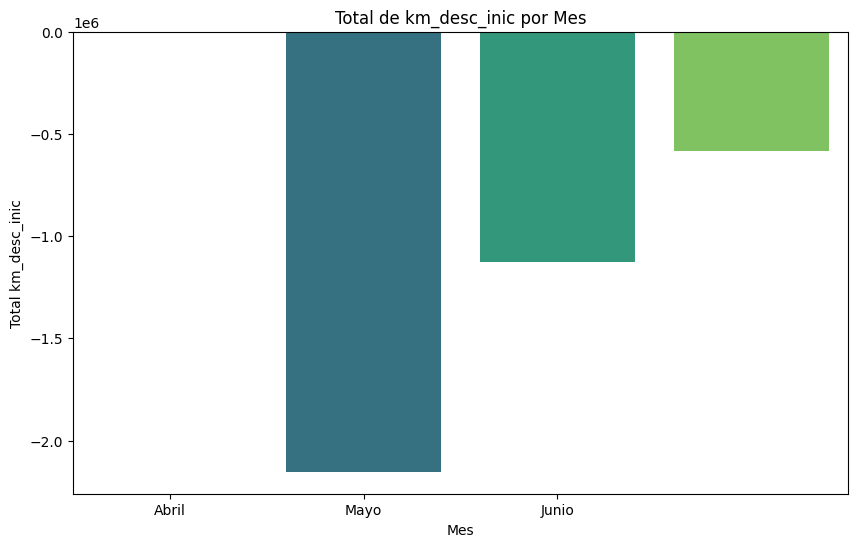

In [17]:
# Agrupar por 'Mes' y sumar 'km_desc_inic'
km_por_mes = kilometraje.groupby('Mes')['km_desc_inic'].sum().reset_index()

# Crear la gráfica
plt.figure(figsize=(10, 6))
sns.barplot(data=km_por_mes, x='Mes', y='km_desc_inic', palette='viridis')
plt.title('Total de km_desc_inic por Mes')
plt.xlabel('Mes')
plt.ylabel('Total km_desc_inic')
plt.xticks(ticks=[0, 1, 2], labels=['Abril', 'Mayo', 'Junio'])  # Etiquetas específicas para los meses 4, 5 y 6
plt.show()

C:\Users\Jonny Villareal\AppData\Local\Temp\ipykernel_17272\4161780759.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(data=km_por_mes, x='Mes', y='km_desc_inic', palette='viridis')


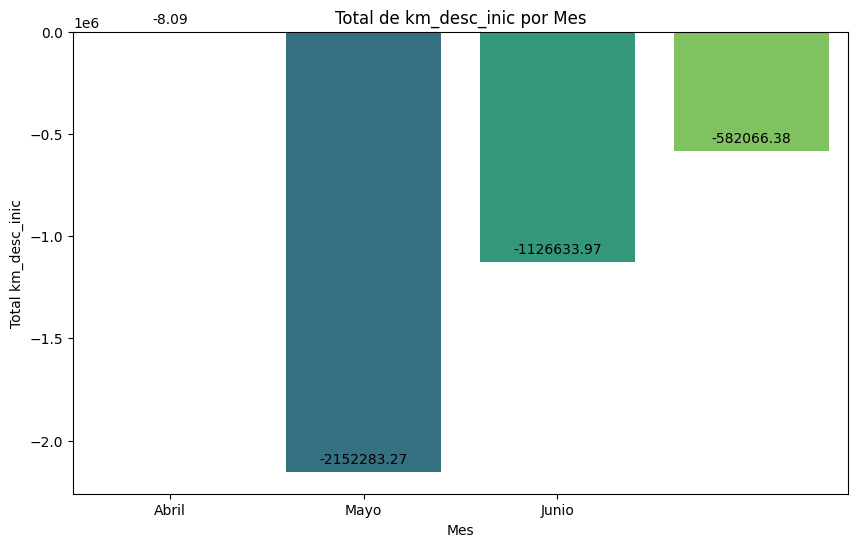

In [18]:
# Agrupar por 'Mes' y sumar 'km_desc_inic'
km_por_mes = kilometraje.groupby('Mes')['km_desc_inic'].sum().reset_index()

# Crear la gráfica
plt.figure(figsize=(10, 6))
barplot = sns.barplot(data=km_por_mes, x='Mes', y='km_desc_inic', palette='viridis')

# Añadir etiquetas de datos encima de cada barra
for p in barplot.patches:
    barplot.annotate(format(p.get_height(), '.2f'), 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha = 'center', va = 'center', 
                     xytext = (0, 9), 
                     textcoords = 'offset points')

# Configurar títulos y etiquetas
plt.title('Total de km_desc_inic por Mes')
plt.xlabel('Mes')
plt.ylabel('Total km_desc_inic')
plt.xticks(ticks=[0, 1, 2], labels=['Abril', 'Mayo', 'Junio'])  # Etiquetas específicas para los meses 4, 5 y 6
plt.show()

In [24]:
# Leer la pestaña 'Acciones'
acciones = pd.read_excel(file_path, sheet_name='Acciones')
print("\nDatos de la pestaña 'Acciones':")

# Asegurarse de que la columna 'Fecha' sea de tipo datetime
acciones['Fecha'] = pd.to_datetime(acciones['Fecha'],  errors='coerce')

# Extraer el mes de la columna 'Fecha' y crear una nueva columna 'Mes'
acciones['Mes'] = acciones['Fecha'].dt.month

# Eliminar filas con valores nulos en la columna 'Fecha'
acciones = acciones.dropna(subset=['Mes'])

# Convertir la columna "IdViaje" a tipo entero
acciones['Mes'] = acciones['Mes'].astype(int)

# Convertir la columna "IdViaje" a tipo entero
acciones['Validación'] = acciones['Validación'].astype(int)

acciones


Datos de la pestaña 'Acciones':


,Fecha,Instante,Linea,Coche,CodigoBus,Accion,NombreUsuario,Puesto,Parametros,Motivo,...,Posicion_inicial,Posicion_final,Servicio,HoraSalida,Evento,POSICION,OBSERVACION,VALIDADO POR,Validación,Mes
0,2024-04-24,07:11:56,1216,14,Z50-2150,27,Jinneth Alexandra Guzman,GMZ02,"<VacioLimitacion Accion=""Vacio"" Desde=""53985"" ...",7,...,1008,8569,CEI1P0012,NaN,Vacio/Limitacion,############,El tecnico le realiza fonia al operador para r...,LEIDY MUÑOZ,0,4
1,2024-04-22,17:12:56,1215,33,Z50-4221,27,Elicia Mongui Duarte,GMZ03,"<VacioLimitacion Accion=""Vacio"" Desde=""53986"" ...",5,...,0,5799,CEI35G020,NaN,Vacio/Limitacion Inicio Viaje - Regulacion,##############################################...,EL tecnico le realiza fonia le indica le envia...,LEIDY MUÑOZ,0,4
2,2024-04-22,17:19:00,1215,33,Z50-4221,27,Elicia Mongui Duarte,GMZ03,"<VacioLimitacion Accion=""Vacio"" Desde=""53986"" ...",5,...,0,6620,CEI35G020,NaN,Vacio/Limitacion Inicio Viaje - Regulacion,##############################################...,EL tecnico le realiza fonia le indica le envia...,LEIDY MUÑOZ,0,4
3,2024-04-23,09:33:24,1185,29,Z50-7111,27,Sonia Constanza Correa Rodriguez,GMZ08,"<VacioLimitacion Accion=""Desvio"" Desde=""54232""...",5,...,0,12786,CEI550029,09:31:17,Vacio/Limitacion Inicio Viaje - Regulacion,##########,El tecnico realiza fonia al operador ya que no...,LEIDY MUÑOZ,0,4
4,2024-05-08,08:51:02,1215,7,Z50-4388,27,Laura Marcela Vargas Gutierrez,GMZ03,"<VacioLimitacion Accion=""Vacio"" Desde=""52372"" ...",5,...,29339,11329,CEI350007,NaN,Inicio Viaje,#############,En actividad bus no se evidencia ninguna accio...,LEIDY MUÑOZ,0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2362,2024-04-24,10:08:18,1385,12,Z50-4007,27,Maicol Alexander Pita Blanco,GMZ01,"<VacioLimitacion Accion=""Vacio"" Desde=""52877"" ...",5,...,402,8620,CEI8Z0012,12:33:01,Vacio/Limitacion,02:24:43,Tecnico realiza fonia para regular el operador...,LEIDY MUÑOZ,1,4
2363,2024-05-07,05:06:47,1413,8,Z50-4101,27,Bryan Guzman,GMZ01,"<VacioLimitacion Accion=""Desvio"" Desde=""53562""...",7,...,494,3988,NaN,NaN,NaN,##############################################...,Tecnico realiza fonia para regular pero solo e...,LEIDY MUÑOZ,1,5
2364,2024-05-08,09:29:31,1216,4,Z50-4439,27,Maicol Alexander Pita Blanco,GMZ02,"<VacioLimitacion Accion=""Vacio"" Desde=""53784"" ...",5,...,633,9583,CEI1P0010,09:29:01,Vacio/Limitacion,#############,Tecnico realiza fonia para regularlo el cual s...,LEIDY MUÑOZ,1,5
2365,2024-05-08,09:31:21,1216,4,Z50-4439,27,Maicol Alexander Pita Blanco,GMZ02,"<VacioLimitacion Accion=""Vacio"" Desde=""53532"" ...",5,...,1920,10101,CEI1P0010,09:33:24,Vacio/Limitacion,00:02:03,Tecnico realiza fonia para regularlo el cual s...,LEIDY MUÑOZ,1,5


In [31]:
# Convertir la columna 'Instante' a cadena de caracteres (str)
acciones['Instante'] = acciones['Instante'].astype(str)

# Verificar que la columna 'Instante' esté presente y convertir
if 'Instante' in acciones.columns:
    acciones['Franja'] = acciones['Instante'].str.slice(0, 2).astype(int)
    
    # Mostrar los primeros registros para verificar
    print(acciones[['Instante', 'Franja']].head())
else:
    print("La columna 'Instante' no está presente en la pestaña 'Acciones'.")

acciones

   Instante  Franja
0  07:11:56       7
1  17:12:56      17
2  17:19:00      17
3  09:33:24       9
4  08:51:02       8


,Fecha,Instante,Linea,Coche,CodigoBus,Accion,NombreUsuario,Puesto,Parametros,Motivo,...,Posicion_final,Servicio,HoraSalida,Evento,POSICION,OBSERVACION,VALIDADO POR,Validación,Mes,Franja
0,2024-04-24,07:11:56,1216,14,Z50-2150,27,Jinneth Alexandra Guzman,GMZ02,"<VacioLimitacion Accion=""Vacio"" Desde=""53985"" ...",7,...,8569,CEI1P0012,NaN,Vacio/Limitacion,############,El tecnico le realiza fonia al operador para r...,LEIDY MUÑOZ,0,4,7
1,2024-04-22,17:12:56,1215,33,Z50-4221,27,Elicia Mongui Duarte,GMZ03,"<VacioLimitacion Accion=""Vacio"" Desde=""53986"" ...",5,...,5799,CEI35G020,NaN,Vacio/Limitacion Inicio Viaje - Regulacion,##############################################...,EL tecnico le realiza fonia le indica le envia...,LEIDY MUÑOZ,0,4,17
2,2024-04-22,17:19:00,1215,33,Z50-4221,27,Elicia Mongui Duarte,GMZ03,"<VacioLimitacion Accion=""Vacio"" Desde=""53986"" ...",5,...,6620,CEI35G020,NaN,Vacio/Limitacion Inicio Viaje - Regulacion,##############################################...,EL tecnico le realiza fonia le indica le envia...,LEIDY MUÑOZ,0,4,17
3,2024-04-23,09:33:24,1185,29,Z50-7111,27,Sonia Constanza Correa Rodriguez,GMZ08,"<VacioLimitacion Accion=""Desvio"" Desde=""54232""...",5,...,12786,CEI550029,09:31:17,Vacio/Limitacion Inicio Viaje - Regulacion,##########,El tecnico realiza fonia al operador ya que no...,LEIDY MUÑOZ,0,4,9
4,2024-05-08,08:51:02,1215,7,Z50-4388,27,Laura Marcela Vargas Gutierrez,GMZ03,"<VacioLimitacion Accion=""Vacio"" Desde=""52372"" ...",5,...,11329,CEI350007,NaN,Inicio Viaje,#############,En actividad bus no se evidencia ninguna accio...,LEIDY MUÑOZ,0,5,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2362,2024-04-24,10:08:18,1385,12,Z50-4007,27,Maicol Alexander Pita Blanco,GMZ01,"<VacioLimitacion Accion=""Vacio"" Desde=""52877"" ...",5,...,8620,CEI8Z0012,12:33:01,Vacio/Limitacion,02:24:43,Tecnico realiza fonia para regular el operador...,LEIDY MUÑOZ,1,4,10
2363,2024-05-07,05:06:47,1413,8,Z50-4101,27,Bryan Guzman,GMZ01,"<VacioLimitacion Accion=""Desvio"" Desde=""53562""...",7,...,3988,NaN,NaN,NaN,##############################################...,Tecnico realiza fonia para regular pero solo e...,LEIDY MUÑOZ,1,5,5
2364,2024-05-08,09:29:31,1216,4,Z50-4439,27,Maicol Alexander Pita Blanco,GMZ02,"<VacioLimitacion Accion=""Vacio"" Desde=""53784"" ...",5,...,9583,CEI1P0010,09:29:01,Vacio/Limitacion,#############,Tecnico realiza fonia para regularlo el cual s...,LEIDY MUÑOZ,1,5,9
2365,2024-05-08,09:31:21,1216,4,Z50-4439,27,Maicol Alexander Pita Blanco,GMZ02,"<VacioLimitacion Accion=""Vacio"" Desde=""53532"" ...",5,...,10101,CEI1P0010,09:33:24,Vacio/Limitacion,00:02:03,Tecnico realiza fonia para regularlo el cual s...,LEIDY MUÑOZ,1,5,9


In [22]:
# Calcular las acciones únicas 

unicas = acciones['Mes'].unique()

print(unicas)

[4 5 6]


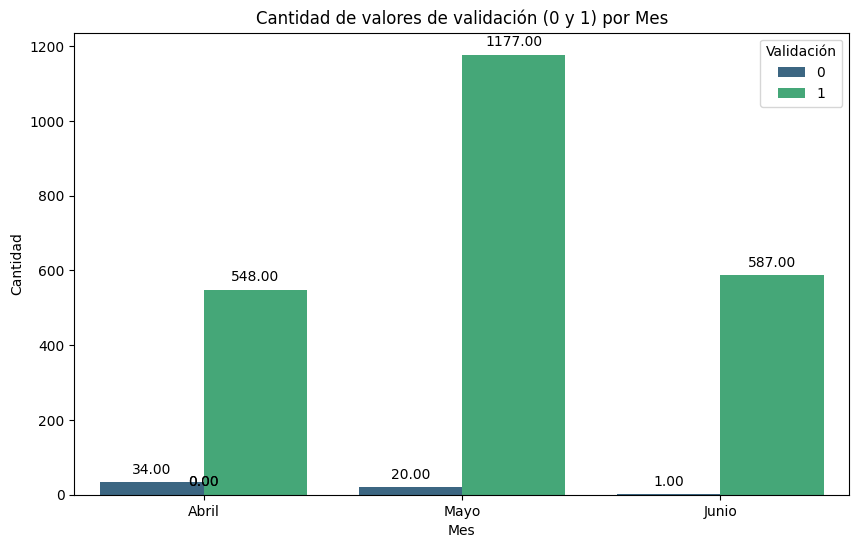

In [28]:
# Agrupar por 'Mes' y 'validación' y contar los valores
validacion_por_mes = acciones.groupby(['Mes', 'Validación']).size().reset_index(name='counts')

# Crear la gráfica
plt.figure(figsize=(10, 6))
barplot = sns.barplot(data=validacion_por_mes, x='Mes', y='counts', hue='Validación', palette='viridis')

# Añadir etiquetas de datos encima de cada barra
for p in barplot.patches:
    barplot.annotate(format(p.get_height(), '.2f'), 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha = 'center', va = 'center', 
                     xytext = (0, 9), 
                     textcoords = 'offset points')

# Configurar títulos y etiquetas
plt.title('Cantidad de valores de validación (0 y 1) por Mes')
plt.xlabel('Mes')
plt.ylabel('Cantidad')
plt.xticks(ticks=[0, 1, 2], labels=['Abril', 'Mayo', 'Junio'])  # Etiquetas específicas para los meses 4, 5 y 6
plt.legend(title='Validación')
plt.show()

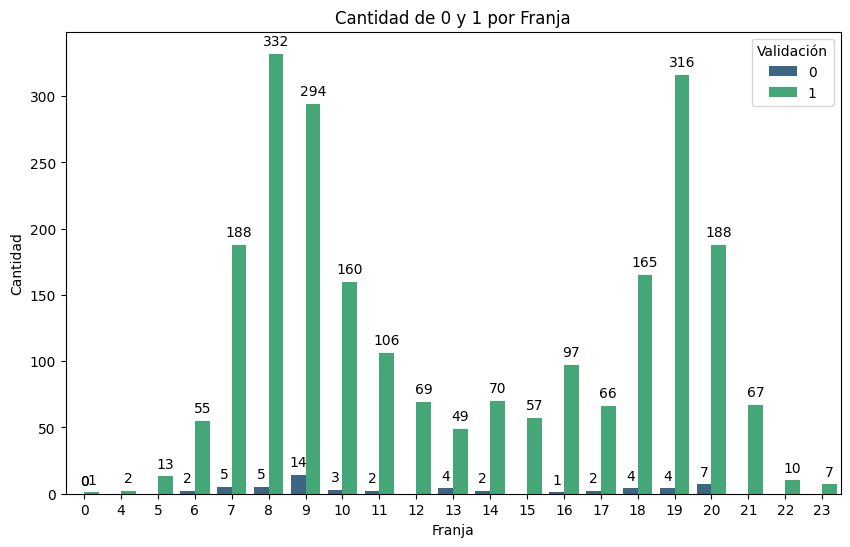

In [32]:
# Agrupar por Franja y contar la cantidad de 0 y 1 en la columna Validación
validacion_por_franja = acciones.groupby(['Franja', 'Validación']).size().reset_index(name='counts')

# Crear la gráfica de barras
plt.figure(figsize=(10, 6))
barplot = sns.barplot(data=validacion_por_franja, x='Franja', y='counts', hue='Validación', palette='viridis')

# Añadir etiquetas de datos encima de cada barra
for p in barplot.patches:
    barplot.annotate(format(p.get_height(), '.0f'),
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha = 'center', va = 'center',
                     xytext = (0, 9),
                     textcoords = 'offset points')

# Configuraciones adicionales
plt.title('Cantidad de 0 y 1 por Franja')
plt.xlabel('Franja')
plt.ylabel('Cantidad')
plt.legend(title='Validación')

# Mostrar la gráfica
plt.show()